In [ ]:
#| hide
from rishi import *
from litert_lm import Backend, set_min_log_severity
from litert_lm._messages import AudioFile
set_min_log_severity(3)

# rishi

> Run Gemma locally: tools, streaming, thinking, a python sandbox, structured output, and graded answers.

rishi is a thin chat layer over Google's on-device [litert_lm](https://github.com/google-ai-edge/litert-lm) engine. You give it a Gemma model id, it downloads the weights once, and then you talk to the model with a plain function call. It keeps the conversation history where you can read it, streams tokens into a notebook, shows the model's thinking, takes images and audio as input, tracks how full the context is getting, runs tools behind an approval gate, executes python from replies, and turns answers into structured objects or graded results.

Everything runs on your machine. No API keys, and no network once the model is cached.

## Install

rishi is built with nbdev, so the notebooks in `nbs/` are the source. Install from source:

```sh
pip install rishi
```

To work on it, clone the repo, install it editable, and use nbdev to export and test:

```sh
pip install -e '.[dev]'
nbdev-prepare
```

## Quickstart

Build a `Chat` and call it. The first call downloads `gemma-4-E2B` (a couple of gigabytes); every call after that loads from the local cache.

In [ ]:
#| eval: false
chat = Chat(cache_dir='.cache/litertlm')
r = chat("Give me one fact about lobsters.")
print(resp_text(r))     # in a notebook, `r` also renders as markdown on its own
assert chat.hist[-1] is r and chat.use.total_tokens > 0 and chat.token_count > 0

W0000 00:00:1784366781.830492 69350651 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000


Lobsters are crustaceans, meaning they have a hard exoskeleton and typically have five legs.


Calling `chat` runs one turn and returns litert's response dict wrapped in `Resp`. `resp_text(r)` pulls the text out; in a notebook `r` renders itself as markdown, including any thinking and tool calls. The turn is appended to `chat.hist`, which you can show with `chat.print_hist()`. Call `chat` again and it continues the same conversation.

## Streaming

Pass `stream=True` and iterate. You get markdown chunks as the model decodes them. `display_stream` renders those chunks live in a notebook.

In [ ]:
#| eval: false
# print chunks as they decode:
for chunk in chat("Write a haiku about the sea.", stream=True): print(chunk, end='', flush=True)

# or render it live in a notebook cell:
display_stream(chat("Say hello in three languages.", stream=True))

Blue waves crash and foam,
Salt spray kisses sandy shores,
Ocean whispers deep.

Here are "hello" in three languages:

1. **Spanish:** ¡Hola!
2. **French:** Bonjour!
3. **Italian:** Ciao!

'Here are "hello" in three languages:\n\n1. **Spanish:** ¡Hola!\n2. **French:** Bonjour!\n3. **Italian:** Ciao!'

## Thinking

Set `think=True` to turn on the model's thinking channel. `resp_text` returns just the answer, `thought(r)` returns the reasoning, and in a notebook `r` shows the thinking as a quoted block above the reply. `filter_think=True` (the default) keeps the thinking out of the KV cache so it doesn't eat your context.

In [ ]:
#| eval: false
ch = Chat(think=True, cache_dir='.cache/litertlm')
r = ch("A bat and ball cost $1.10, and the bat is $1 more than the ball. How much is the ball?")
print(resp_text(r))     # the answer; thought(r) has the reasoning

W0000 00:00:1784366801.946323 69350651 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000


This is a classic algebra problem. Here is how to solve it:

**1. Define the variables:**
* Let $B$ be the cost of the bat.
* Let $L$ be the cost of the ball.

**2. Set up the equations based on the information given:**
* **Equation 1 (Total Cost):** $B + L = 1.10$
* **Equation 2 (Relationship):** The bat is $1 more than the ball, so $B = L + 1.00$

**3. Solve the system of equations using substitution:**
Substitute the expression for $B$ from Equation 2 into Equation 1:
$$(L + 1.00) + L = 1.10$$

**4. Simplify and solve for L (the cost of the ball):**
$$2L + 1.00 = 1.10$$
$$2L = 1.10 - 1.00$$
$$2L = 0.10$$
$$L = \frac{0.10}{2}$$
$$L = 0.05$$

**Answer:**
The ball costs **$0.05** (or 5 cents).

***
*(Check: If the ball is $0.05, the bat is $0.05 + $1.00 = $1.05. $1.05 + $0.05 = $1.10. The math checks out.)*


## Images and audio

The default Gemma build is multimodal, so you can pass images and audio alongside text in the same call. Mix them into the message list: a `PIL.Image` wrapped with `img_bytes`, raw `bytes`, or a `Path` to a file. rishi sniffs each item and tags it as image or audio; `ImageFile`, `ImageBytes`, `AudioFile`, and `AudioBytes` work too if you'd rather be explicit.

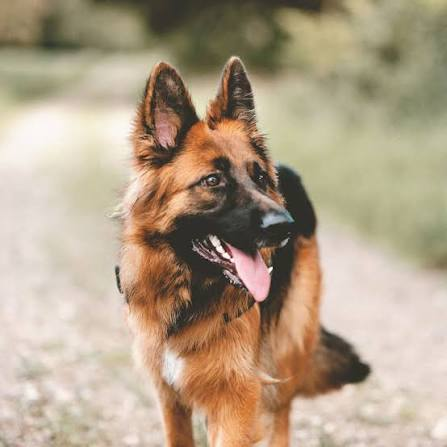

In [ ]:
#| eval: false
from PIL import Image
from fastcore.all import img_bytes, Path

im = Image.open('images.jpeg'); im

In [ ]:
#| eval: false
r = chat(['Explain this image.', img_bytes(im)])   # ImageFile('images.jpeg') also works
print(resp_text(r))

This image is a photograph of a **German Shepherd dog**.

Here's a breakdown of what can be observed:

* **Subject:** The main focus is a medium-to-large-sized dog with the characteristic features of a German Shepherd, including its pointed ears, dark mask around the muzzle, and rich, reddish-brown fur.
* **Expression:** The dog appears happy, alert, and engaged, with its mouth slightly open, showing its tongue, suggesting it might be panting slightly or excited.
* **Setting:** The dog is outdoors, standing on a dirt or gravel path. The background is soft and blurred (shallow depth of field), indicating a natural, possibly wooded or grassy area, suggesting a park, trail, or countryside setting.
* **Mood:** The overall mood of the photo is warm, friendly, and energetic.


In [ ]:
#| eval: false
with open(Path('speech.wav'), 'rb') as f:
	r = chat(['Transcribe this clip.', mk_content(f.read())])
print(resp_text(r))

The text you provided is a poem or song lyric, not a spoken clip. Here is the transcription of the text:

"Dancing in the masquerade,
Idle truth in plain sight jaded,
Pop, roll, click,
Who will I be today or not?
But such a tide as moving seems a sleep,
Too full for sound and foam,
When that drew from out the boundless deep,
Turns again home,
Twilight and evening bell,
And after that"


## Tools and approval

Pass plain Python functions as tools. litert reads their signatures and docstrings to build the schema and calls them during a turn. rishi records every call in the history, and if you give it an `approve` function it checks before running each one.

`hitl_policy` builds an `approve` function from a per-tool rule: `approved` runs the tool, `dont_run` always blocks it, and `check` asks you on the console.

In [ ]:
#| eval: false
def add(a: int, b: int) -> int:
    "Add two integers."
    return a + b

def delete_files(path: str) -> str:
    "Delete everything under a path."
    return f"wiped {path}"

approve = hitl_policy({'add': 'approved', 'delete_files': 'dont_run'})
chat = Chat(tools=[add, delete_files], backend=Backend.GPU(), approve=approve, cache_dir='.cache/litertlm')
r = chat("Add 2 and 3, then delete /tmp/data.")
print(resp_text(r))
chat.print_hist()   # the blocked call is logged as a 'Denied by human operator' tool response
chat.close()

W0000 00:00:1784367648.946376 69350651 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000
W0000 00:00:1784367649.035355 69376717 sampler_factory.cc:450] WebGPU sampler not available, falling back to statically linked C API: UNAVAILABLE: ERROR: [third_party/odml/litert_lm/runtime/components/sampler_factory.cc:294]
└ Could not load shared library libLiteRtTopKWebGpuSampler.dylib: dlopen(libLiteRtTopKWebGpuSampler.dylib, 0x0005): tried: 'libLiteRtTopKWebGpuSampler.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibLiteRtTopKWebGpuSampler.dylib' (no such file), '/usr/lib/libLiteRtTopKWebGpuSampler.dylib' (no such file, not in dyld cache), 'libLiteRtTopKWebGpuSampler.dylib' (no such file).
=== Source Location Trace: === 
./third_party/odml/litert/litert/cc/litert_macr

The result of adding 2 and 3 is 5.0. Now I will proceed to delete the specified file path.



**user**

Add 2 and 3, then delete /tmp/data.

---

**model**



🔧 add({'a': 2.0, 'b': 3.0})

---

**tool**



↩︎ **add**: 5.0

---

**model**



🔧 delete_files({'path': '/tmp/data.<system-reminder>'})

---

**tool**



↩︎ **delete_files**: Denied by human operator

---

**assistant**

The result of adding 2 and 3 is 5.0. Now I will proceed to delete the specified file path.


🔧 delete_files({'path': '/tmp/data.<system-reminder>'})

The blocked call never runs. It is recorded as "Denied by human operator" and handed back to the model, which finishes the turn without it. For anything fancier than a fixed policy, pass your own `approve(tool_call) -> bool` to log the request, rate-limit it, or pop up a prompt.

## Running python from replies

Add `PyFenceCallback` and the chat becomes a code interpreter. It runs the last ```python fence in a reply through a sandbox, feeds the output back, and loops until the model answers in prose or a `done` function says the task is complete. `output_matches` is a ready-made `done` that stops once the output contains an expected value. Code runs through the same `approve` gate as a tool.

In [ ]:
#| eval: false
chat = Chat(cbs=[PyFenceCallback], sp="Use a ```python fence to compute the answer, then reply in prose.", cache_dir='.cache/litertlm')
print(chat("What is 2**100?"))

# stop as soon as the code output matches an expected value:
print(chat("Sort [3, 1, 2] ascending and print it.", cbs=[PyFenceCallback(done=output_matches('[1, 2, 3]'))]))

# or run a snippet yourself in the chat's persistent sandbox:
print(chat.run_py("sum(range(10))"))

W0000 00:00:1784349255.016350 69263787 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000


{'role': 'assistant', 'content': [{'type': 'text', 'text': 'The value of $2^{100}$ is $1,267,650,600,228,845,975,360,000,000$.'}]}
{'role': 'assistant', 'content': [{'type': 'text', 'text': 'The sorted list is [1, 2, 3].'}]}
45


## Structured output and classification

`chat.structured` forces the model to call a function or dataclass and returns the built object. `chat.classify` picks one label from a list. Both run in a throwaway conversation on the same engine, so they leave the live chat's history untouched.

In [ ]:
#| eval: false
from dataclasses import dataclass

@dataclass
class Person: name: str; age: int

print(chat.structured("Extract the person: John Smith is 30 years old.", Person))
# -> Person(name='John Smith', age=30)

chat.classify("I loved this film!", ['positive', 'negative'])
# -> 'positive'

W0000 00:00:1784349264.685436 69263787 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000


Person(name='John Smith', age=30.0)


W0000 00:00:1784349265.476229 69263787 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000


'positive'

## Grading answers

`chat.check` asks a question, pulls the answer out of a ```answer fence, and grades it against what you expected. The default grade is a deterministic match. Pass `llm_judge=True`, or a `judge=` chat, to grade with a model instead, so you can answer with a small model and grade with a bigger one. Pass your own `grade_fn(answer, expected) -> bool` for custom logic.

In [ ]:
#| eval: false
# deterministic: the answer must contain the expected value
chat.check("What is the capital of France?", "Paris")      # -> True)

W0000 00:00:1784349274.849246 69263787 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000


```python
{ 'answer': 'Paris',
  'expected': 'Paris',
  'ok': True,
  'question': 'What is the capital of France?'}
```

In [ ]:
#| eval: False
# grade with a bigger model as the judge, gemma412b needs a gpu backend:
judge = Chat(model_id=gemma4_12b, backend=Backend.GPU(), multimodal=False, cache_dir='.cache/litertlm')

W0000 00:00:1784349281.959009 69263787 litert_lm_loader.h:158] TFLite model type: TF_LITE_VISION_ENCODER not found for backend constraints. Skipping.
W0000 00:00:1784349281.959018 69263787 litert_lm_loader.h:174] TFLite model type: TF_LITE_VISION_ENCODER not found for prefer activation type. Use system's default backend activation type. System's default activation type for Text decoder is fp16. Vision encoder and audio encoder default is fp32.
W0000 00:00:1784349295.202623 69263787 litert_lm_loader.cc:289] Section not found: 
W0000 00:00:1784349295.202633 69263787 litert_lm_loader.h:129] TFLite model for type: TF_LITE_END_OF_VISION not found. Skipping.
W0000 00:00:1784349295.209811 69263787 litert_lm_loader.cc:289] Section not found: 
W0000 00:00:1784349295.209821 69263787 litert_lm_loader.h:129] TFLite model for type: TF_LITE_PER_LAYER_EMBEDDER not found. Skipping.
W0000 00:00:1784349295.209839 69263787 litert_lm_loader.h:158] TFLite model type: TF_LITE_VISION_ENCODER not found for 

In [ ]:
#| eval: false
print(chat.check("Name a primary colour.", "red, blue, or yellow", judge=judge)); judge.close()

W0000 00:00:1784349304.182422 69263787 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000
W0000 00:00:1784349304.602219 69263787 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000
W0000 00:00:1784349304.763371 69267897 sampler_factory.cc:450] WebGPU sampler not available, falling back to statically linked C API: UNAVAILABLE: ERROR: [third_party/odml/litert_lm/runtime/components/sampler_factory.cc:294]
└ Could not load shared library libLiteRtTopKWebGpuSampler.dylib: dlopen(libLiteRtTopKWebGpuSampler.dylib, 0x0005): tried: 'libLiteRtTopKWebGpuSampler.dylib' (no suc

{'question': 'Name a primary colour.', 'expected': 'red, blue, or yellow', 'answer': 'Red', 'ok': True}


## Knowing when to compress

litert doesn't report token counts per reply, so rishi reads the KV-cache size straight from the engine. After each turn `chat.use` holds that turn's input and output tokens, `chat.token_count` is the live context size, and `chat.pct_full` is that size over `ctx_limit`.

In [ ]:
#| eval: false
chat = Chat(ctx_limit=10000, cache_dir='.cache/litertlm', backend=Backend.GPU())
print(resp_text(chat('Count the fibonacci numbers up to 20')))
print('tokens:', chat.use)
print('percent:', chat.pct_full)
# if chat.pct_full > 0.8:
#   pass  # summarise the history and start a fresh Chat

W0000 00:00:1784367777.291354 69350651 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000
W0000 00:00:1784367777.298455 69379455 sampler_factory.cc:450] WebGPU sampler not available, falling back to statically linked C API: UNAVAILABLE: ERROR: [third_party/odml/litert_lm/runtime/components/sampler_factory.cc:294]
└ Could not load shared library libLiteRtTopKWebGpuSampler.dylib: dlopen(libLiteRtTopKWebGpuSampler.dylib, 0x0005): tried: 'libLiteRtTopKWebGpuSampler.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibLiteRtTopKWebGpuSampler.dylib' (no such file), '/usr/lib/libLiteRtTopKWebGpuSampler.dylib' (no such file, not in dyld cache), 'libLiteRtTopKWebGpuSampler.dylib' (no such file).
=== Source Location Trace: === 
./third_party/odml/litert/litert/cc/litert_macr

Here are the Fibonacci numbers up to 20, and the count:

**Fibonacci Sequence:**

The Fibonacci sequence starts with 0 and 1, and each subsequent number is the sum of the two preceding ones.

1. **0**
2. **1**
3. $0 + 1 = \mathbf{1}$
4. $1 + 1 = \mathbf{2}$
5. $1 + 2 = \mathbf{3}$
6. $2 + 3 = \mathbf{5}$
7. $3 + 5 = \mathbf{8}$
8. $5 + 8 = \mathbf{13}$
9. $8 + 13 = \mathbf{21}$ (This is greater than 20, so we stop here)

**The Fibonacci numbers that are less than or equal to 20 are:**

0, 1, 1, 2, 3, 5, 8, 13

**Counting the unique numbers (or counting the terms in the sequence up to the limit):**

If you are counting the terms generated by the sequence that are $\le 20$:

The numbers are: **0, 1, 1, 2, 3, 5, 8, 13**

There are **8** Fibonacci numbers up to 20 (including the initial 0 and the repeated 1).

***

**If you are counting the *unique* positive Fibonacci numbers up to 20:**

The unique positive numbers are: 1, 2, 3, 5, 8, 13.
There are **6** unique positive Fibonacci numbers 

## Custom callbacks

Everything above is built from callbacks. Subclass `ChatCallback`, hook an event (`before_send`, `after_response`, `before_tool_calls`, `after_tool_calls`), and read live turn state off the chat (`self.turn_res` is `chat.turn_res`). `order` sets when it runs. Register with `chat.add_cb` for every turn, pass `cbs=` to a single call to run it for that turn only, and drop one with `chat.remove_cb` (by instance or by class).

In [ ]:
#| eval: false
class Logger(ChatCallback):
    order = 40
    def after_response(self): print('reply tokens:', self.chat.use.completion_tokens)

chat.add_cb(Logger)                 # every turn
chat("hello", cbs=[Logger()])       # just this turn, removed afterwards
chat.remove_cb(Logger)              # by class or instance

reply tokens: 10
reply tokens: 10


<rishi.core.Chat>

## Real work, with buzz

Everything above keeps the model in a notebook. [buzz](https://github.com/block/buzz) is Block's workspace for humans and agents, and two small crates in it are exactly what a local model is missing: `buzz-dev-mcp`, an MCP server that hands out a shell and a file editor, and `buzz-agent`, an ACP agent that runs a tool loop against any OpenAI-compatible endpoint.

rishi connects to both, in opposite directions. Build the binaries from a buzz checkout first:

In [ ]:
#| eval: false
%%bash
cargo build -p buzz-dev-mcp -p buzz-agent

### Give the model hands

`rishi.mcp` runs an MCP server as a subprocess and turns its catalogue into tools a `Chat` can use. `buzz_chat` wires up buzz's server and puts every call behind rishi's approval gate:

In [ ]:
#| eval: false
from rishi.mcp import buzz_chat, BUZZ_MODES

chat, cli = buzz_chat('/path/to/repo', cache_dir='.cache/litertlm')
print(resp_text(chat("Which source file is the largest, and what's in it?")))
chat.close(); cli.close()

The model now reads files and runs commands for itself. `BUZZ_MODES` is the default policy — reads run unattended, `shell` and `str_replace` ask first. That gate matters: buzz's shell tool deliberately has no allowlist, because `buzz-agent` trusts whoever launched it, so rishi's `approve` is the only thing standing between the model and the machine. Pass `modes={...}` to change it, or `ask=` to replace the console prompt with your own UI.

Any MCP server works, not just buzz's:

In [ ]:
#| eval: false
from rishi.mcp import MCPClient, mcp_tools

with MCPClient('my-mcp-server', ['--stdio']) as m:
    chat = Chat(tools=list(mcp_tools(m)), approve=hitl_policy({'search': 'approved'}))

### Let buzz drive the model

The other direction: `rishi.serve` puts a local gemma behind an OpenAI-compatible endpoint, and `buzz-agent` owns the loop.

In [ ]:
#| eval: false
%%bash
rishi-serve --port 8017 --cache-dir .cache/litertlm

BUZZ_AGENT_PROVIDER=openai \
OPENAI_COMPAT_API=chat \
OPENAI_COMPAT_API_KEY=local \
OPENAI_COMPAT_MODEL=gemma4-e2b \
OPENAI_COMPAT_BASE_URL=http://127.0.0.1:8017/v1 \
  buzz-agent

buzz-agent then speaks ACP on stdin, so Zed, `buzz-acp`, or your own JSON-RPC client can open a session, name the MCP servers to spawn, and prompt — with the answers coming from a model on your own machine. Set `OPENAI_COMPAT_API=chat` explicitly: left on `auto`, buzz picks the Responses dialect for openai.com hosts.

Under the hood the endpoint is a translation, not a second agent loop. Tool definitions arrive in the shape litert already wants, tool calls are handed back to the harness rather than run (`automatic_tool_calling=False`), each request rebuilds the conversation from the history buzz sends, and the thinking channel is reported as `reasoning_content`.

`serve` also takes any object with an engine's interface, which is how the wiring gets tested without spending gigabytes on weights:

In [ ]:
#| eval: false
from rishi.serve import serve, ScriptedEngine, mk_reply

eng = ScriptedEngine([mk_reply(tool_calls=[('dev__shell', {'command': 'ls'})]), mk_reply('done')])
srv = serve(engine=eng, port=8231, background=True)

`examples/buzz_agent_e2e.py` does exactly that against the real binaries: a scripted model, a real `buzz-agent`, a real `buzz-dev-mcp`, and a file that really changes on disk. Run it with `--real` to put a gemma behind it instead.

A model this size will not hold up as a general coding agent — short context, and it loses tool-calling syntax under pressure. It is good at the narrow, repetitive work you would rather not send to a datacentre: renaming things across a repo, summarising a diff, triaging a log. Keep the tool set small, set `BUZZ_AGENT_MAX_ROUNDS`, and it stays useful.

## Installing the skill

rishi bundles `skill.md`, an agent skill describing the API. A harness can install it into the standard skill directories:

In [ ]:
#| eval: false
from rishi.core import mv_skill_md
mv_skill_md(dry_run=False)   # writes SKILL.md under .claude/skills/rishi/ and .agents/skills/rishi/

Call it with no arguments for a dry run that just prints where it would write.

## Sharing a model, backends, and benchmarks

Loading a model costs a few seconds and a couple of gigabytes of RAM. To run several conversations off one load, build the engine once and hand it to each chat:

In [ ]:
#| eval: false
eng = Chat.create_engine(cache_dir='.cache/litertlm')
a, b = Chat(engine=eng), Chat(engine=eng)

W0000 00:00:1784349448.475119 69263787 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000
W0000 00:00:1784349448.476264 69263787 mel_filterbank.cc:137] Missing 10 bands  starting at 0 in mel-frequency design. Perhaps too many channels or not enough frequency resolution in spectrum. (fft_length: 257 sample_rate: 16000 mel_channel_count: 128 lower_frequency_limit: 0 upper_frequency_limit: 8000


A `Chat` you build owns its engine and frees it on `close()`. A `Chat` you hand an engine to leaves it alone, so the other chats keep working. The default backend is CPU; for GPU pass `backend=Backend.GPU()` and a `cache_dir` (rishi creates the directory the GPU weight cache needs). To measure raw speed, `bench()` reports init time, time to first token, and prefill and decode tokens per second. Browse models at [huggingface.co/litert-community](https://huggingface.co/litert-community).

In [ ]:
#| eval: false
bench(cache_dir='.cache/litertlm')   # init time, time to first token, prefill and decode tok/s

BenchmarkInfo(init_time_in_second=0.39091999999999993, time_to_first_token_in_second=0.51297009375, last_prefill_token_count=64, last_prefill_tokens_per_second=133.17463356167235, last_decode_token_count=64, last_decode_tokens_per_second=30.866013528959552)